<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-5/ML_LAB_5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning Laboratory Experiment: kNN Handwritten Digit Classification

This notebook demonstrates the use of a k-Nearest Neighbors (kNN) classifier to identify handwritten digits based on their appearance similarity with a sample dataset. We will use the built-in Scikit-learn handwritten digits dataset for this experiment.

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# ============================================
# 2. LOAD HANDWRITTEN DIGITS DATASET
# ============================================

digits = load_digits()
X = digits.data
y = digits.target

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# ============================================
# 3. UNDERSTAND DATASET SHAPE AND FEATURES
# ============================================

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features (pixels): {X.shape[1]}")
print(f"Number of target classes: {len(np.unique(y))}")

Dataset Shape: (1797, 64)
Target Shape: (1797,)
Number of samples: 1797
Number of features (pixels): 64
Number of target classes: 10


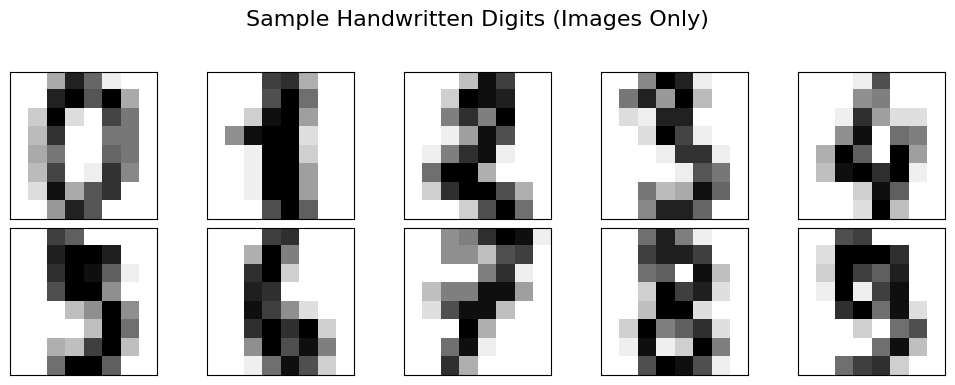

In [4]:
# ============================================
# 4. VISUALIZE SAMPLE HANDWRITTEN DIGITS
# ============================================

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for ax, image in zip(axes.flat, digits.images):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Sample Handwritten Digits (Images Only)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

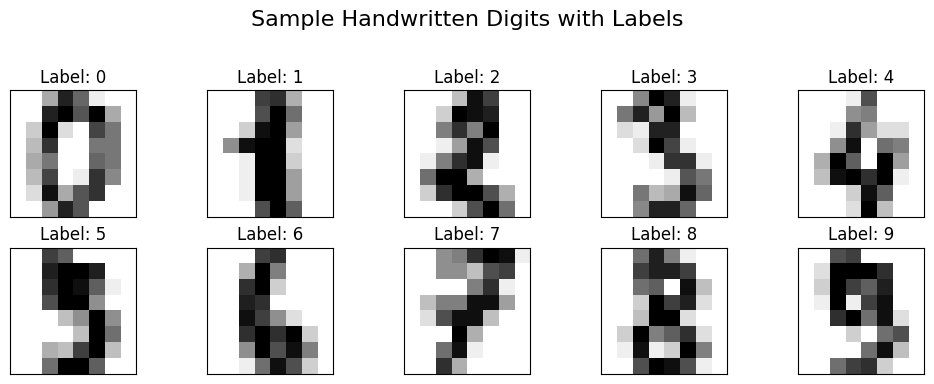

In [5]:
# ============================================
# 5. DISPLAY DIGIT IMAGES WITH THEIR LABELS
# ============================================

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for i, (ax, image, label) in enumerate(zip(axes.flat, digits.images, digits.target)):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Label: {label}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Sample Handwritten Digits with Labels', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
# ============================================
# 6. PREPARE TRAINING AND TESTING DATA
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1437, 64)
X_test shape: (360, 64)
y_train shape: (1437,)
y_test shape: (360,)


In [7]:
# ============================================
# 7. FEATURE SCALING
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


In [8]:
# ============================================
# 8. CREATE kNN CLASSIFIER
# ============================================

knn_classifier = KNeighborsClassifier(n_neighbors=3)

print("kNN classifier created with n_neighbors=3.")

kNN classifier created with n_neighbors=3.


In [9]:
# ============================================
# 9. TRAIN THE kNN MODEL
# ============================================

knn_classifier.fit(X_train_scaled, y_train)

print("kNN model trained successfully.")

kNN model trained successfully.


In [10]:
# ============================================
# 10. PREDICT TEST DATA
# ============================================

y_pred = knn_classifier.predict(X_test_scaled)

print("Predictions on test data generated.")

Predictions on test data generated.


In [11]:
# ============================================
# 11. CALCULATE ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the kNN model: {accuracy:.4f}")

Accuracy of the kNN model: 0.9667


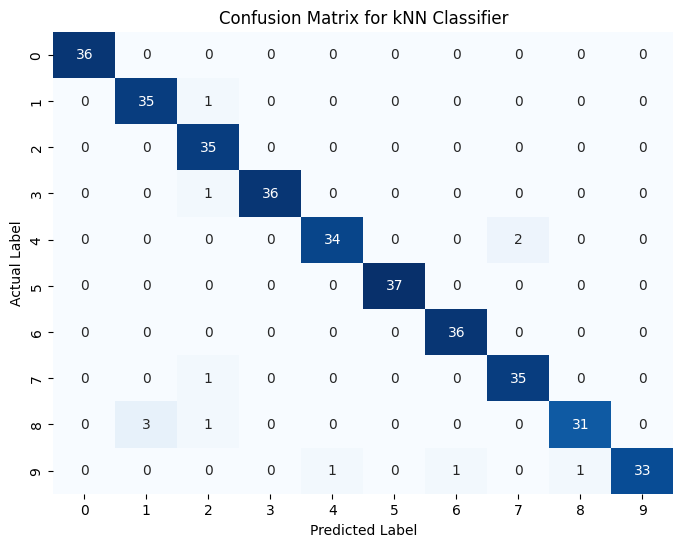

In [12]:
# ============================================
# 12. GENERATE CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for kNN Classifier')
plt.show()

In [13]:
# ============================================
# 13. GENERATE CLASSIFICATION REPORT
# ============================================

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.90      1.00      0.95        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.97      0.89      0.93        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



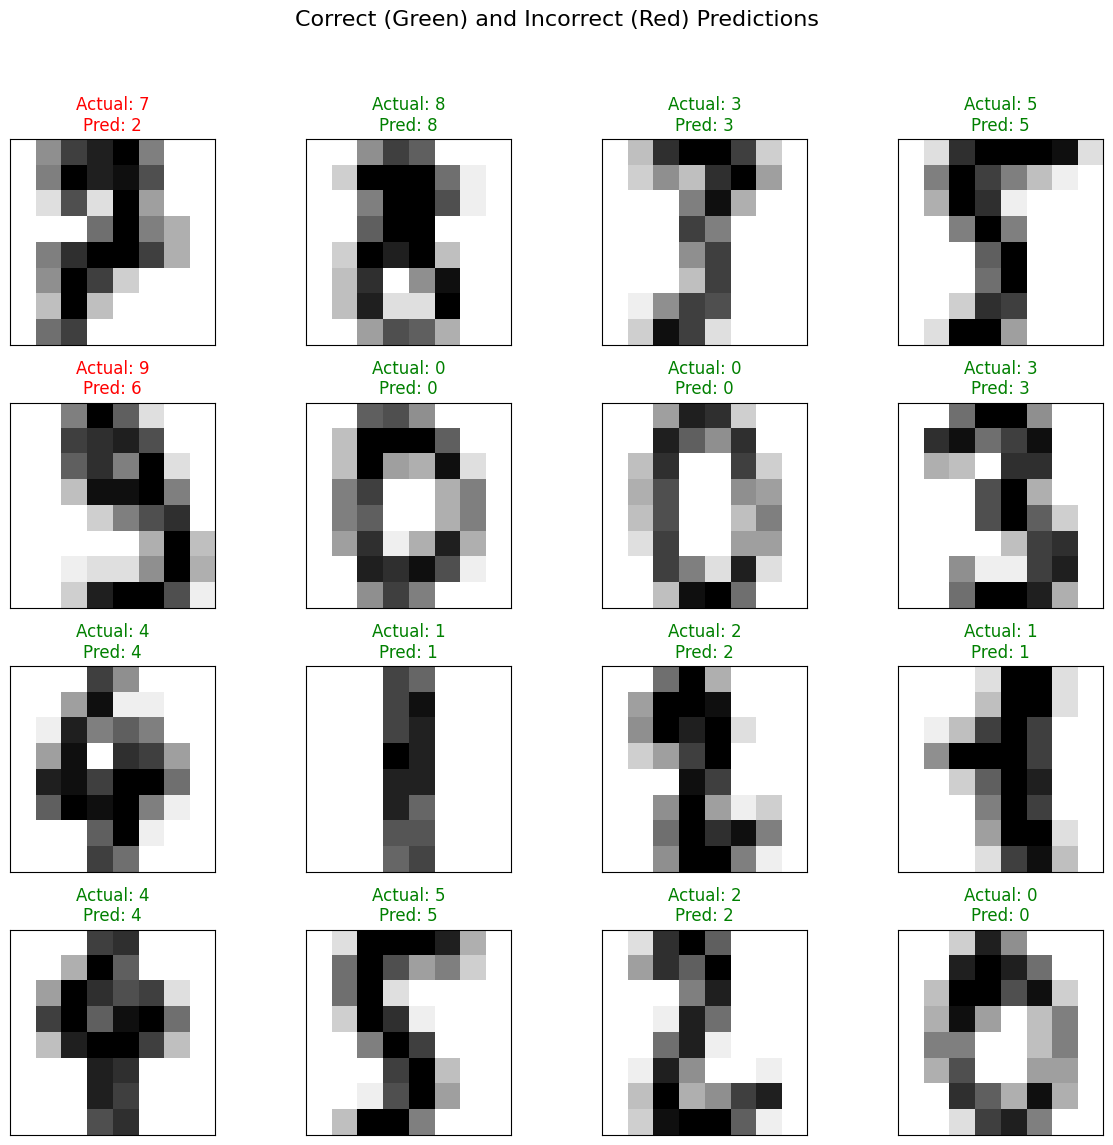

In [14]:
# ============================================
# 14. VISUALIZE CORRECT AND INCORRECT PREDICTIONS
# ============================================

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 12))

num_samples_to_display = 16
indices = np.random.choice(len(X_test), num_samples_to_display, replace=False)

for i, ax in enumerate(axes.flat):
    if i < num_samples_to_display:
        idx = indices[i]
        image_data = X_test[idx].reshape(8, 8)
        true_label = y_test[idx]
        predicted_label = y_pred[idx]

        ax.imshow(image_data, cmap=plt.cm.gray_r, interpolation='nearest')
        title_color = 'green' if true_label == predicted_label else 'red'
        ax.set_title(f'Actual: {true_label}\nPred: {predicted_label}', color=title_color)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.axis('off')

plt.suptitle('Correct (Green) and Incorrect (Red) Predictions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

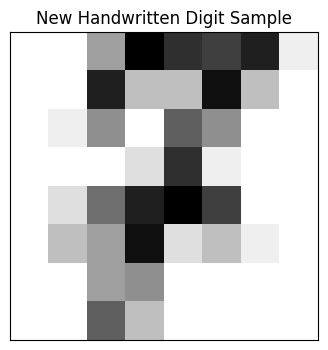

Actual digit: 7
Predicted digit: 7


In [15]:
# ============================================
# 15. PREDICT A NEW HANDWRITTEN DIGIT
# ============================================

new_digit_index = 4
new_digit_sample = X_test[new_digit_index]
actual_digit_label = y_test[new_digit_index]

new_digit_sample_reshaped = new_digit_sample.reshape(1, -1)
new_digit_sample_scaled = scaler.transform(new_digit_sample_reshaped)

predicted_new_digit = knn_classifier.predict(new_digit_sample_scaled)

plt.figure(figsize=(4, 4))
plt.imshow(new_digit_sample.reshape(8, 8), cmap=plt.cm.gray_r, interpolation='nearest')
plt.title('New Handwritten Digit Sample')
plt.xticks([])
plt.yticks([])
plt.show()

print(f"Actual digit: {actual_digit_label}")
print(f"Predicted digit: {predicted_new_digit[0]}")

### Conclusion

This laboratory experiment successfully demonstrated the application of a k-Nearest Neighbors classifier for handwritten digit recognition using the Scikit-learn digits dataset. Based on the calculated test accuracy of `0.9667` and the detailed classification report, the kNN model proved to be effective in classifying handwritten digits, showing strong performance across most classes. The confusion matrix further illustrated the model's strengths and areas where misclassifications occurred. This experiment confirms kNN's utility for classification tasks where similarity between data points is a key distinguishing factor.